In [1]:
# data handling
import pandas as pd
import numpy as np
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [2]:
df = pd.read_csv(r"C:\Users\Windows\Downloads\nova_pay_combined.csv")

# Data Wrangling

In [3]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [4]:
df.tail()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,...,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,...,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,...,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,...,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0
11399,fdffeb16-192a-4483-9b1e-9928e23269c2,b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9,2025-11-29 20:10:47.573611+00:00,US,USD,NGN,web,1214.16,1214.16,19.34,...,1.000,low,58,0.187,0,0.646,4,6,0.25,1


In [5]:
df.shape

(11400, 26)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [7]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

Insight: From the data info and is_Null, there are some missing data which need to be addressed wrong data type

In [8]:
df.duplicated().any()


np.True_

Checking for data imbalance

In [9]:
df["is_fraud"].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [10]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.912544
1    0.087456
Name: proportion, dtype: float64

In [11]:
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")

Fraud rate: 8.75%


Converting timestamp from object to time format

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')

In [13]:
print("First:", df["timestamp"].min())

First: 2022-10-03 18:40:59.468549+00:00


In [14]:
print("Last:", df["timestamp"].max())

Last: 2025-12-16 00:13:41.468549+00:00


In [15]:
# Count invalid timestamps
invalid_ts =df["timestamp"].isna().sum()
print(invalid_ts)

61


Correcting for invalid time stamp and missing date

In [16]:
median_date = df["timestamp"].median()
df["timestamp"] = df["timestamp"].fillna(median_date)

In [17]:
# Extract time features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek + 1
df["month"] = df["timestamp"].dt.month
df["is_weekend"] = df["day_of_week"].isin([6, 7]).astype(int)

In [18]:
numeric_cols = ["fee", "amount_usd",  "device_trust_score"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [19]:
# Checking for missing values left
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                      0
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
hour                           0
day_of_week                    0
month                          0
is_weekend                     0
dtype: int

We are using Unknow to filling missing vlaue for IP address and IP countey in that these are sensitive information peculiar to individual customers. And filling the missing of know your customer with mode since it is catagorical variable.

In [20]:
#  IP Address
if "ip_address" in df.columns:
    # Create missing flag
    df["ip_missing"] = df["ip_address"].isna().astype(int)
    # Fill with 'Unknown'
    df["ip_address"] = df["ip_address"].fillna("Unknown")
    print(f"IP missing count: {df["ip_missing"].sum()}")

IP missing count: 305


In [21]:
#  IP Country
if "ip_country" in df.columns:
    # Create missing flag
    df["ipc_missing"] = df["ip_country"].isna().astype(int)
    # Fill with 'Unknown'
    df["ip_country"] = df["ip_country"].fillna("Unknown")
    print(f"IPC missing count: {df["ipc_missing"].sum()}")

IPC missing count: 301


In [22]:
if "kyc_tier" in df.columns:
    df["kyc_missing"] = df["kyc_tier"].isna().astype(int)
    df["kyc_tier"] = df["kyc_tier"].str.lower().str.strip().fillna(df["kyc_tier"].mode()[0])
    print(f"Missing: {df["kyc_missing"].sum()}")

Missing: 300


In [23]:
df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
ip_missing                   0
ipc_missing                  0
kyc_miss

Some columns which supposed not to have negative values, do have, which need to be addressed.

In [24]:
negative_check_cols = ["fee", "device_trust_score", "risk_score_internal", "txn_velocity_1h"]

for col in negative_check_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"Fixing {neg_count} negative values in {col}")
            # Replace negatives with median of positive values
            median_val = df[df[col] >= 0][col].median()
            df.loc[df[col] < 0, col] = median_val


Fixing 101 negative values in fee
Fixing 204 negative values in device_trust_score
Fixing 204 negative values in txn_velocity_1h


Fixing Features which values are less than zero or greater than one which are supposed to be between zero and one.

In [25]:
if "ip_risk_score" in df.columns:
    invalid = ((df["ip_risk_score"] < 0) | (df["ip_risk_score"] > 1)).sum()
    if invalid > 0:
        print(f"Fixing {invalid} invalid ip_risk_score values")
        df.loc[df["ip_risk_score"] < 0, "ip_risk_score"] = 0
        df.loc[df["ip_risk_score"] > 1, "ip_risk_score"] = 1

Fixing 204 invalid ip_risk_score values


In [26]:
if "device_trust_score" in df.columns:
    invalid = ((df["device_trust_score"] < 0) | (df["device_trust_score"] > 1)).sum()
    if invalid > 0:
        print(f"Fixing {invalid} invalid device_trust_score values")
        df.loc[df["device_trust_score"] < 0, "device_trust_score"] = 0
        df.loc[df["device_trust_score"] > 1, "device_trust_score"] = 1

Standardising Some columns which has inconsistent spelling.

In [27]:
# Standardise channel
if "channel" in df.columns:
    df["channel"] = df["channel"].str.lower().str.strip()
    # Map variations to standard categories
    channel_map = {
        "weeb": "web", "ATM": "atm", 'mobille': 'mobile',"web": "web",'mobile': 'mobile'
    }
    df['channel'] = df['channel'].replace(channel_map)

In [28]:
# Standardise kyc_tier
if "kyc_tier" in df.columns:
    df["kyc_tier"] = df["kyc_tier"].str.lower().str.strip()
    kyc_map = {
        "standard": "standard", "standrd": "standard",
        "enhanced": "enhanced", "enhancd": "enhanced", "low": "low"
    }
    df["kyc_tier"] = df["kyc_tier"].replace(kyc_map)

Encoding some features or columns for easy recognision by ML model.

In [29]:
if "kyc_tier" in df.columns:
    kyc_map = {"standard": 0, "enhanced": 1, "low": 2}
    df["kyc_tier_encoded"] = df["kyc_tier"].map(kyc_map)

In [30]:
if "new_device" in df.columns:
    df["new_device"] = df["new_device"].map({"TRUE": 1, "FALSE": 0, True: 1, False: 0})

if "location_mismatch" in df.columns:
    df["location_mismatch"] = df["location_mismatch"].map({"TRUE": 1, "FALSE": 0, True: 1, False: 0})

In [31]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,corridor_risk,is_fraud,hour,day_of_week,month,is_weekend,ip_missing,ipc_missing,kyc_missing,kyc_tier_encoded
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,...,0.0,0,18,1,10,0,0,0,0,0.0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.0,0,20,1,10,0,0,0,0,0.0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.0,0,23,1,10,0,0,0,0,1.0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.0,0,1,2,10,0,0,0,0,0.0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.0,0,9,2,10,0,0,0,0,1.0


Checking for duplicate(s) and dropping the duplicate(s)if any

In [32]:
df.duplicated().any()


np.True_

In [33]:
df.drop_duplicates(inplace=True)

**## # Exploratory Data Analysis (EDA)**

Starting with checking info and Summary Statistics

In [34]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,corridor_risk,is_fraud,hour,day_of_week,month,is_weekend,ip_missing,ipc_missing,kyc_missing,kyc_tier_encoded
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,...,0.0,0,18,1,10,0,0,0,0,0.0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.0,0,20,1,10,0,0,0,0,0.0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.0,0,23,1,10,0,0,0,0,1.0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.0,0,1,2,10,0,0,0,0,0.0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.0,0,9,2,10,0,0,0,0,1.0


In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11200 non-null  object             
 1   customer_id                11200 non-null  object             
 2   timestamp                  11200 non-null  datetime64[ns, UTC]
 3   home_country               11200 non-null  object             
 4   source_currency            11200 non-null  object             
 5   dest_currency              11200 non-null  object             
 6   channel                    11200 non-null  object             
 7   amount_src                 11200 non-null  object             
 8   amount_usd                 11200 non-null  float64            
 9   fee                        11200 non-null  float64            
 10  exchange_rate_src_to_dest  11200 non-null  float64            
 11  device_

Insight: After data preprocessing the total transction has reduced from 11,400 to 11,200. This is mainly attributed to duplicates dropped. 

Noticed that amount source was suppossed to be in float format and not object and having a negative number.

In [36]:
# converting to float from object
df["amount_src"] = pd.to_numeric(df["amount_src"],errors="coerce")

In [37]:
# Replace negative amounts with median
negative_count = (df["amount_src"] < 0).sum()
if negative_count > 0:
    median_amount = df["amount_src"].median()
    df.loc[df["amount_src"] < 0, "amount_src"] = median_amount
    print(f"Replaced {negative_count} negative amounts with median: {median_amount}")

Replaced 100 negative amounts with median: 158.925


In [38]:
#Numeric Data Summary
df.describe()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,...,corridor_risk,is_fraud,hour,day_of_week,month,is_weekend,ip_missing,ipc_missing,kyc_missing,kyc_tier_encoded
count,11196.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,...,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11166.000000
mean,439.125155,443.990433,96.773922,167.453693,0.119286,0.162946,0.393969,392.848571,0.666898,0.049375,...,0.045406,0.088839,11.521071,3.966696,6.517857,0.277679,0.026786,0.026429,0.026339,0.352230
std,1359.524985,1382.918826,940.231922,381.930143,0.324139,0.369333,0.261774,342.123998,0.249747,0.258388,...,0.084876,0.284524,6.899241,1.993618,3.441894,0.447874,0.161464,0.160413,0.160149,0.644775
min,7.230000,7.230000,0.500000,0.592000,0.000000,0.000000,0.004000,1.000000,0.005000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,92.597500,93.997500,2.450000,1.000000,0.000000,0.000000,0.209000,147.000000,0.522000,0.000000,...,0.000000,0.000000,6.000000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,158.937500,163.480000,3.500000,7.142857,0.000000,0.000000,0.325000,293.000000,0.658000,0.000000,...,0.000000,0.000000,11.000000,4.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,294.880000,296.075000,5.470000,73.529412,0.000000,0.000000,0.488000,661.000000,0.894000,0.000000,...,0.050000,0.000000,18.000000,6.000000,10.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,11942.890000,12498.570000,9999.990000,1388.888889,1.000000,1.000000,1.000000,1095.000000,0.999000,2.000000,...,0.250000,1.000000,23.000000,7.000000,12.000000,1.000000,1.000000,1.000000,1.000000,2.000000


## Summary Statistic for non numeric features

In [39]:
#Categorical Data Summary
df.describe(include = ["object", "bool"])

,transaction_id,customer_id,home_country,source_currency,dest_currency,channel,device_id,ip_address,ip_country,kyc_tier
count,11200,11200,11200,11200,11200,11200,11200,11200,11200,11200
unique,11200,1315,7,3,9,4,2113,10901,10,5
top,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,US,USD,NGN,mobile,e70db499-19e1-4927-b04f-3ebfcf62e33c,Unknown,US,standard
freq,1,1483,7784,7875,1447,6395,85,300,6713,8280


Analysing of Target Variable  (Fraud Distribution)

is_fraud
0    10205
1      995
Name: count, dtype: int64
is_fraud
0    0.911161
1    0.088839
Name: proportion, dtype: float64


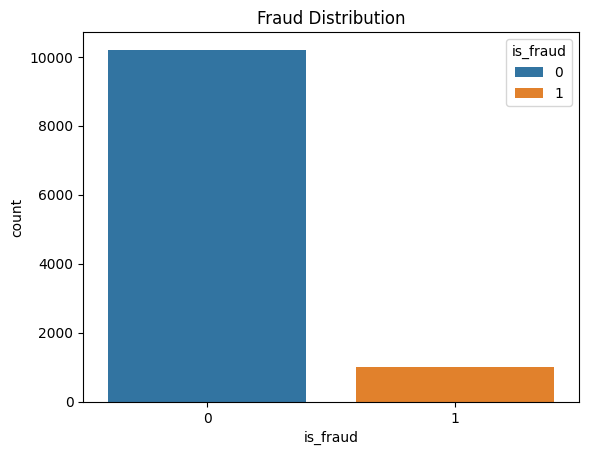

In [153]:
# Fraud distribution
print(df["is_fraud"].value_counts())
print(df["is_fraud"].value_counts(normalize=True))

# Visualise
sns.countplot(x="is_fraud", data=df, hue = "is_fraud")
plt.title("Fraud Distribution")
plt.show()

Insight: It can be seen that the target variable has a high class imbalance

Missing Value Analysis

transaction_id                0
customer_id                   0
timestamp                     0
home_country                  0
source_currency               0
dest_currency                 0
channel                       0
amount_src                    4
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_address                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                      0
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
hour                          0
day_of_week                   0
month                         0
is_weekend                    0
ip_missing                    0
ipc_miss

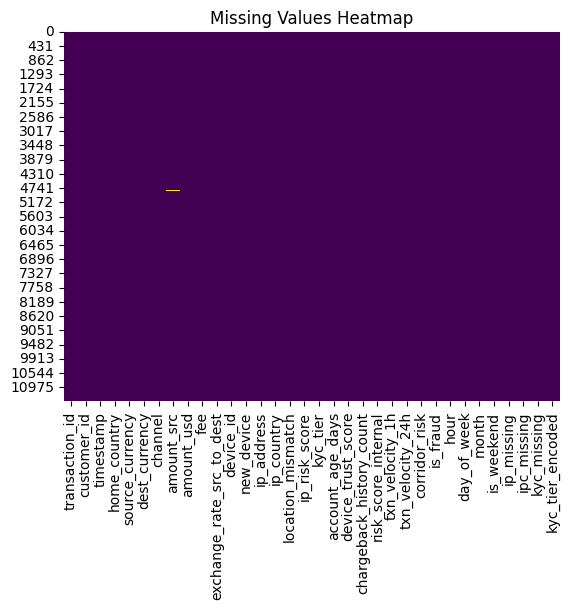

In [41]:
# Missing values
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

# Visualise missing
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [42]:
print(df.isnull().sum())

transaction_id                0
customer_id                   0
timestamp                     0
home_country                  0
source_currency               0
dest_currency                 0
channel                       0
amount_src                    4
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_address                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                      0
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
hour                          0
day_of_week                   0
month                         0
is_weekend                    0
ip_missing                    0
ipc_miss

Missing Valuee wwere noticed in the features which has to be corrected and missing value analysis will be repeated

In [43]:
df["kyc_tier_encoded"].unique()

array([ 0.,  1.,  2., nan])

In [44]:
df["kyc_tier_encoded"] = df["kyc_tier_encoded"].fillna(0)

In [45]:
df["kyc_tier_encoded"].unique()

array([0., 1., 2.])

In [46]:
df["amount_src"] = df["amount_src"].fillna(df["amount_src"].median())


In [47]:
print(df.isnull().sum())

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
ip_missing                   0
ipc_missing                  0
kyc_miss

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
ip_missing                   0
ipc_missing                  0
kyc_miss

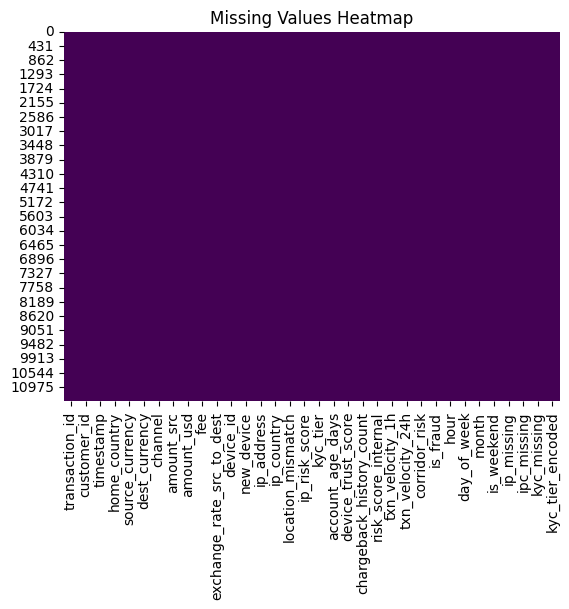

In [48]:
# Missing values
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

# Visualise missing
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

Insight: No more missing Value

## Numerical Analysis

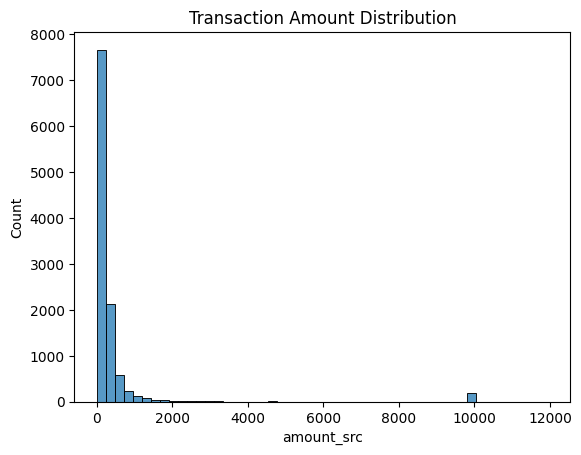

In [49]:
# Distribution of amount
sns.histplot(df["amount_src"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

Insight:The source amount is skewed to the right(positively skewed) showing presence of outlier in it. Solution to this is to log transform the feature.

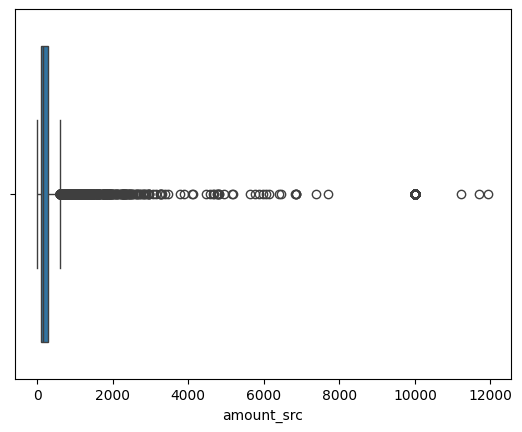

In [50]:
# Boxplot to see outliers
sns.boxplot(x=df['amount_src'])
plt.show()

In [51]:
# Checking for correlation of the target varible to all the numeric features in our dataset
df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)

is_fraud                     1.000000
txn_velocity_24h             0.752129
txn_velocity_1h              0.691234
risk_score_internal          0.603606
chargeback_history_count     0.580417
ip_risk_score                0.544245
location_mismatch            0.420506
new_device                   0.379840
kyc_tier_encoded             0.372066
corridor_risk                0.194903
exchange_rate_src_to_dest    0.152899
amount_usd                   0.131013
amount_src                   0.130932
month                        0.013835
day_of_week                  0.001438
is_weekend                  -0.000203
fee                         -0.013441
kyc_missing                 -0.037640
ipc_missing                 -0.037752
ip_missing                  -0.038197
hour                        -0.086858
account_age_days            -0.285965
device_trust_score          -0.437196
Name: is_fraud, dtype: float64

This gives an idea of our feature selection

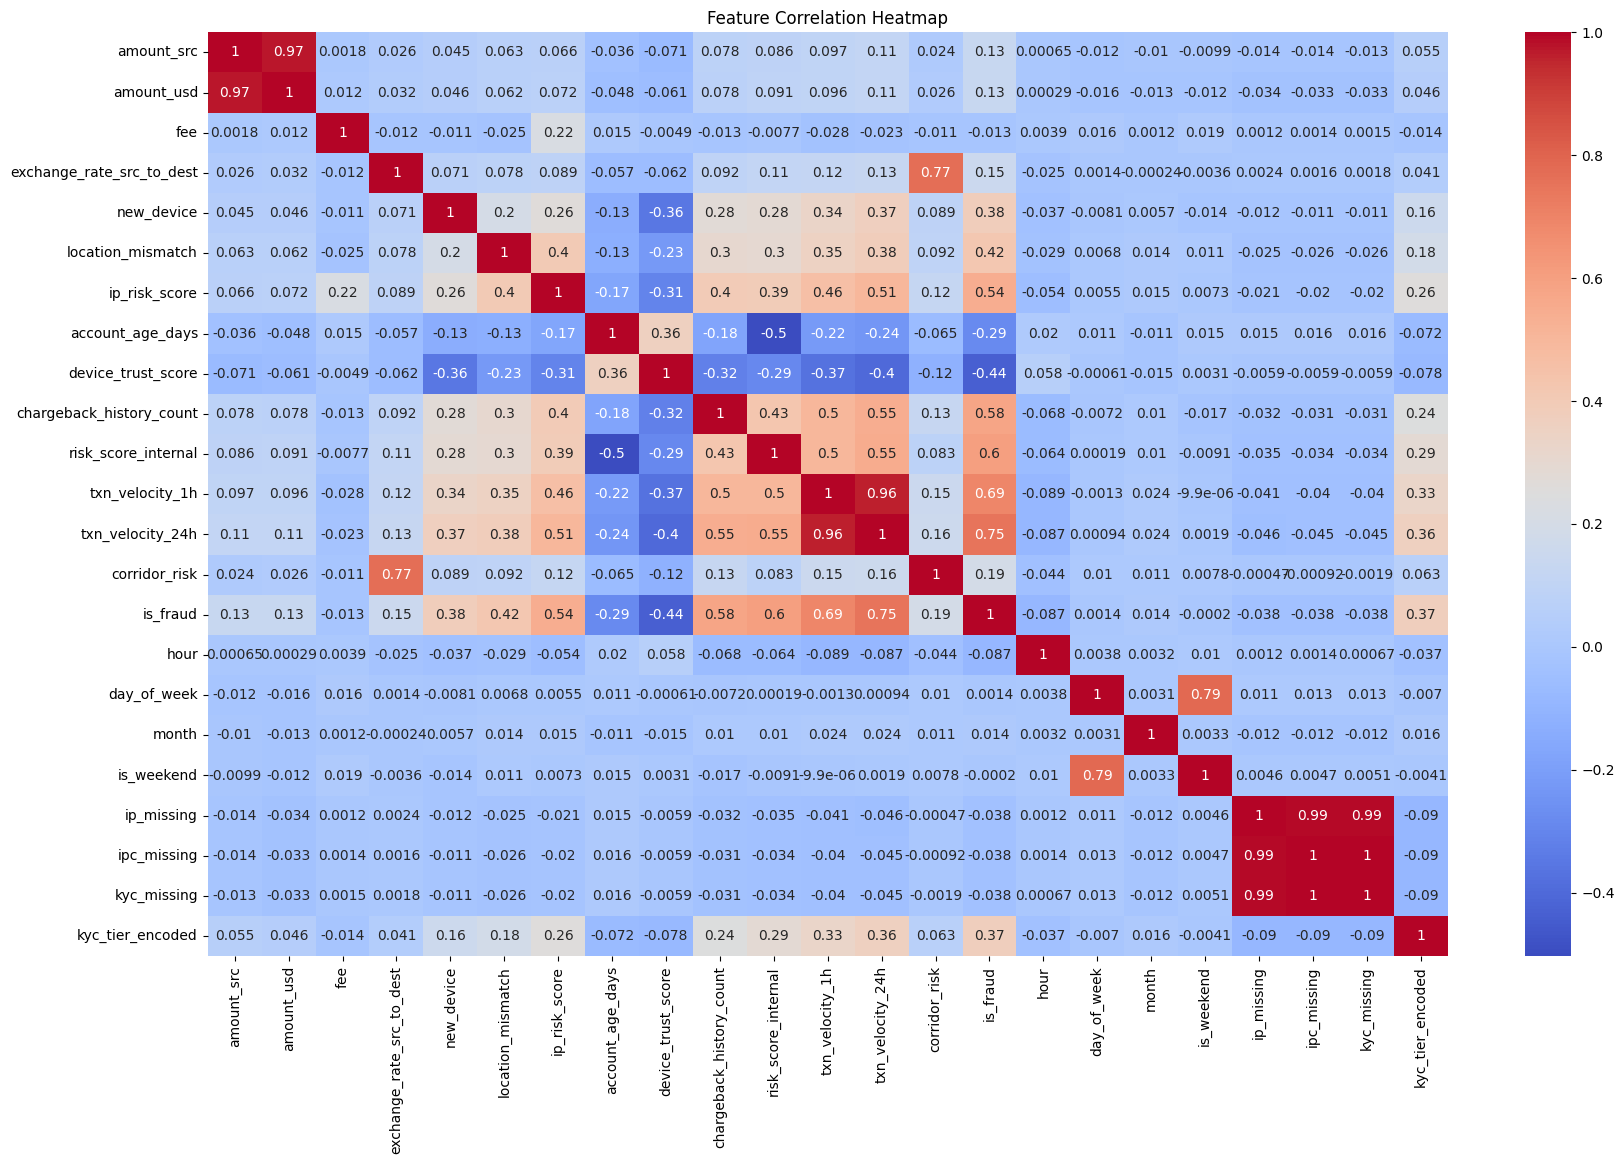

In [52]:
 # Correlation heatmap - Checking for multicollinearity
plt.figure(figsize=(20, 12))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

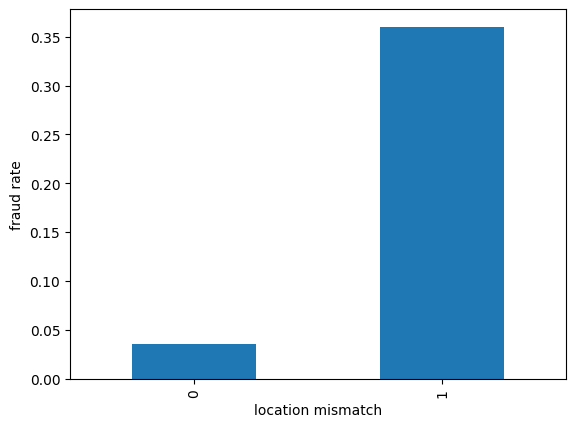

In [53]:
df.groupby("location_mismatch")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("location mismatch")
plt.show()

Insight: This means that when there is location mismatch there is higher likelihood (7 times) of fraud

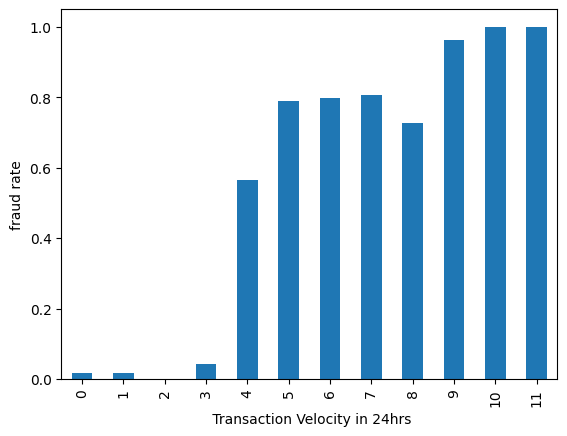

In [54]:
df.groupby("txn_velocity_24h")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel(" Transaction Velocity in 24hrs")
plt.show()

Insight: This suggests that the higher the number of transactions an individual transacts in a day (24hrs) the higher the likelihood of being fraud expecially when it is unsual. 

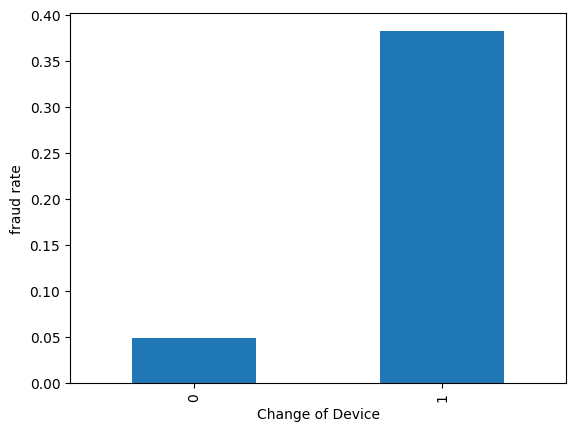

In [55]:
df.groupby("new_device")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("Change of Device")
plt.show()

Insight: where there is a change of device used for transaction  there is 8 time chances of being a fruadulent transaction.

Catagorical Analysis

In [56]:
cat_cols = df.select_dtypes(include = ["object", "category", "bool"]).columns
cat_cols

Index(['transaction_id', 'customer_id', 'home_country', 'source_currency',
       'dest_currency', 'channel', 'device_id', 'ip_address', 'ip_country',
       'kyc_tier'],
      dtype='object')

channel
mobile     6395
web        3766
atm        1002
unknown      37
Name: count, dtype: int64


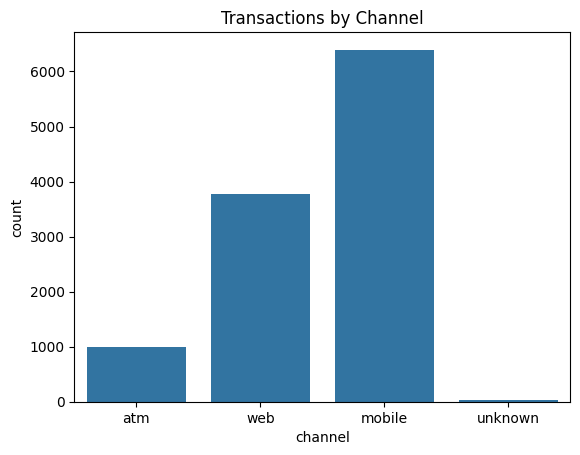

In [57]:
# Channel distribution
print(df["channel"].value_counts())
sns.countplot(x="channel", data=df)
plt.title('Transactions by Channel')
plt.show()

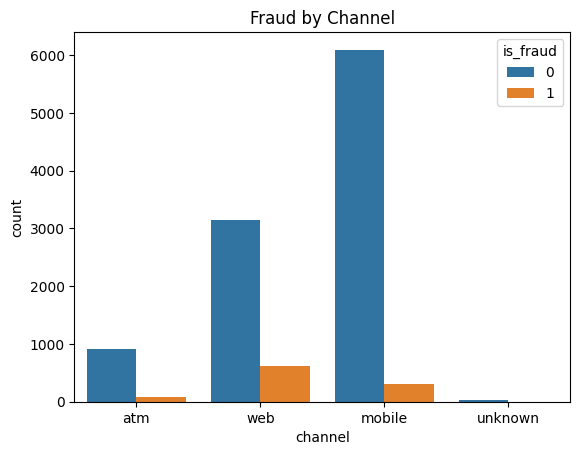

In [58]:
# Fraud by channel
sns.countplot(x="channel", hue="is_fraud", data=df)
plt.title('Fraud by Channel')
plt.show()

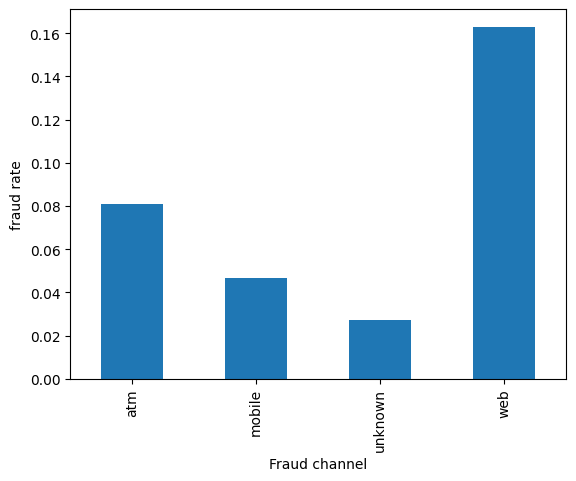

In [59]:
df.groupby("channel")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("Fraud channel")
plt.show()

Insight: Most frauds are perpetrated via the web channel followed by atm, and mobile then unknown channel.

In [60]:
df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
ip_missing                   0
ipc_missing                  0
kyc_miss

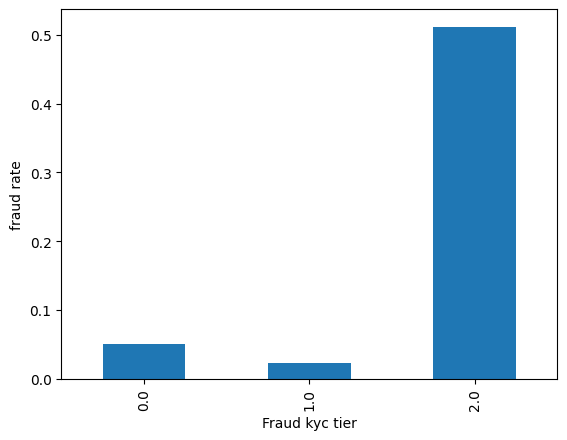

In [61]:
df.groupby("kyc_tier_encoded")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("Fraud kyc tier")
plt.show()

Insight: the Know Your customer tier(KYC),  Enhance which means fully verified customers encoded with 1  shows the lowest fraud perpetration rate, standard encode with 0 which represent base line verification show the next low likelyhood of fraud perpetration low verification encoded with 2 shows by far high fraud rate.

In [62]:
# Checking for wrong formatting of home country
df["home_country"].unique()

array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
      dtype=object)

In [63]:
df["home_country"] = df["home_country"].str.lower().str.strip()

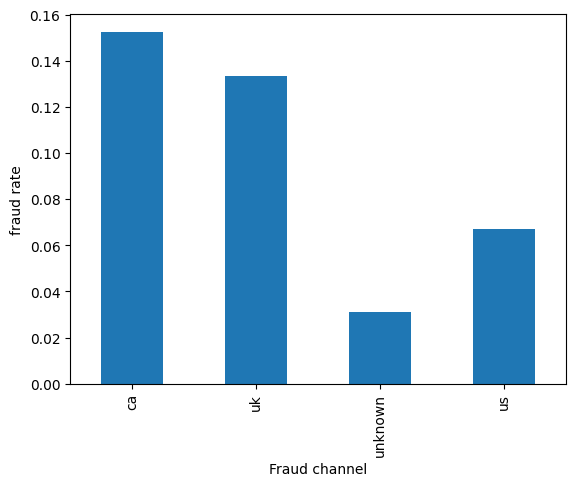

In [64]:
df.groupby("home_country")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("Fraud channel")
plt.show()

Insight: This suggests that most fraud was perpetrated in Canada, by the UK then the US

Temporal Analysis

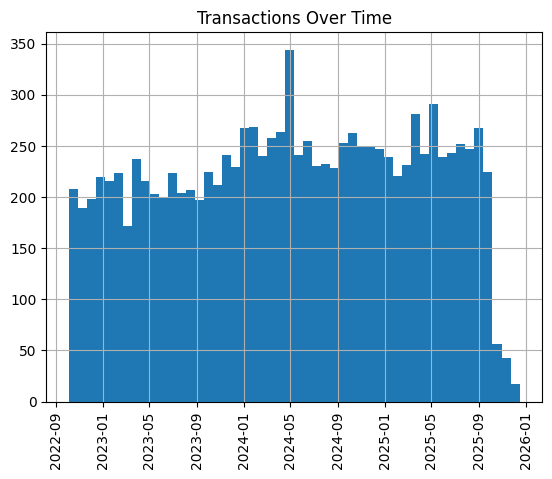

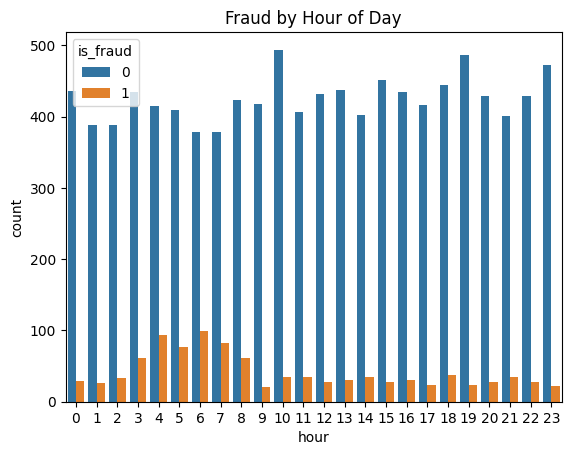

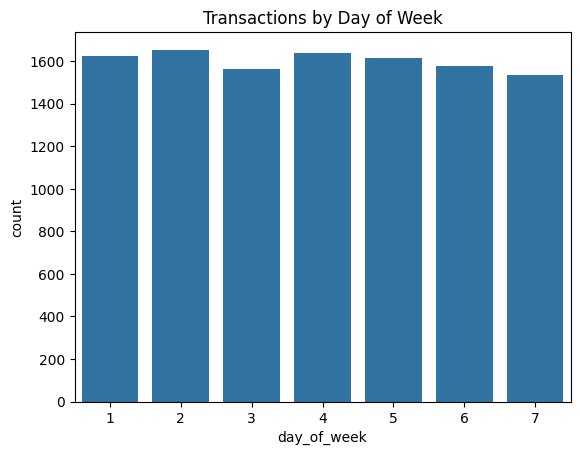

is_weekend
0    0.088875
1    0.088746
Name: is_fraud, dtype: float64


In [65]:
# Transactions over time
df["timestamp"].hist(bins=50)
plt.title("Transactions Over Time")
plt.xticks(rotation=90)
plt.show()

# Fraud by hour
sns.countplot(x="hour", hue="is_fraud", data=df)
plt.title('Fraud by Hour of Day')
plt.show()

# Transactions by day of week
sns.countplot(x="day_of_week", data=df)
plt.title("Transactions by Day of Week")
plt.show()

# Weekend vs weekday
print(df.groupby("is_weekend")["is_fraud"].mean())

Insight: The chart suggest that fraud is common from 0400 hours to 0800 hours. And most transaction occur wekk days that is Monday to friday

Feature Engineering

Time-Based Features: During Preprocesing some time-based column where created some will be added

In [66]:
df["is_night"] = df["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)  # Late night
df["is_business_hours"] = df["hour"].between(9, 17).astype(int)
df["is_lunch_hour"] = df["hour"].isin([12, 13, 14]).astype(int)
df["is_friday_night"] = ((df["day_of_week"] == 5) & (df["hour"] >= 18)).astype(int)
df["is_weekend_night"] = ((df["is_weekend"] == 1) & (df["is_night"] == 1)).astype(int)

Insight: These features are meant to capture unsual timing as fraud usually occurs at odd hours (night, weekends, friday night), while normal user stick to business hour.

Transaction Velocity features

In [67]:
# velocity features
df["high_velocity_1h"] = (df["txn_velocity_1h"] > df["txn_velocity_1h"].quantile(0.95)).astype(int)
df["high_velocity_24h"] = (df["txn_velocity_24h"] > df["txn_velocity_24h"].quantile(0.95)).astype(int)

# Velocity change
df["velocity_change"] = df["txn_velocity_24h"] - df["txn_velocity_1h"]

These features flag suspicious activity burst, unsual daily activity, and sudden activity spikes that often indicate fraud.

Amount-Based Features

In [68]:
# Log transform (reduces skewness)
df["amount_log"] = np.log1p(df["amount_src"])

# Amount categories
df["amount_category"] = pd.qcut(df["amount_src"], q=5, labels=["very_low", "low", "medium", "high", "very_high"])

# Amount rounding (fraudsters often use round numbers)
df["amount_rounded"] = (df["amount_src"] == df["amount_src"].round()).astype(int)
df["amount_whole"] = (df["amount_src"] % 1 == 0).astype(int)

# High amount flag
df["high_amount"] = (df["amount_src"] > df["amount_src"].quantile(0.95)).astype(int)

These features capture different aspects of transaction amounts in size and in shape giving the model signals to detect fraud patterns.

Risk Score features

In [69]:
# Combined risk score
df["combined_risk"] = (
    df['ip_risk_score'] * 0.3 + 
    (1 - df['device_trust_score']) * 0.3 + 
    df['risk_score_internal'] * 0.4
)

# Risk categories
df["ip_risk_high"] = (df["ip_risk_score"] > 0.5).astype(int)
df["device_low_trust"] = (df["device_trust_score"] < 0.5).astype(int)

# Corridor risk categories
df["high_corridor_risk"] = (df["corridor_risk"] > df["corridor_risk"].quantile(0.75)).astype(int)

Thease features combine and categorise risk signals that combined is weighted is average, while the flags flag the highest-risk cases for the model

In [70]:
df["high_corridor_risk"].unique()

array([0, 1])

Behavioural Features

In [71]:
# Account age categories
df["account_age_years"] = df["account_age_days"] / 365
df["new_account"] = (df["account_age_days"] < 30).astype(int)

# Chargeback history
df["has_chargeback"] = (df["chargeback_history_count"] > 0).astype(int)

These features capture customers risk signals: older accounts are more trusted, new accounts are suspicious, and prior  chargebacks indicates risky customer.

Currency Features

In [72]:
# Currency change
df["currency_change"] = (df["source_currency"] != df["dest_currency"]).astype(int)

# Fee ratio
df["fee_ratio"] = df["fee"] / (df["amount_src"] + 1)

# Exchange rate extreme
df["extreme_exchange_rate"] = (df["exchange_rate_src_to_dest"] > df["exchange_rate_src_to_dest"].quantile(0.95)).astype(int)

These features flag suspicious currency changes , unsual fee patterns and extremeexchange rates that may indicate fraud

Interaction Features

In [73]:
# New device + low KYC
df["new_device_low_kyc"] = ((df["new_device"] == 1) & (df["kyc_tier_encoded"] == 0)).astype(int)

# Location mismatch + high amount
df["location_mismatch_high_amount"] = ((df["location_mismatch"] == 1) & (df["high_amount"] == 1)).astype(int)

# New device + high velocity
df["new_device_high_velocity"] = ((df["new_device"] == 1) & (df["high_velocity_24h"] == 1)).astype(int)

These features  capture risk combinations: fraud is most likely when multiple risk factors  occur together

Building a Baseline Models

In [74]:
""" Checking for correlation of the target variable to all the numeric 
features in our dataset after feature engineering process"""

df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)

is_fraud                         1.000000
txn_velocity_24h                 0.752129
combined_risk                    0.700784
txn_velocity_1h                  0.691234
velocity_change                  0.668769
has_chargeback                   0.608847
risk_score_internal              0.603606
chargeback_history_count         0.580417
high_velocity_24h                0.553063
ip_risk_score                    0.544245
high_velocity_1h                 0.492809
new_device_high_velocity         0.481207
device_low_trust                 0.445294
ip_risk_high                     0.443712
location_mismatch                0.420506
new_account                      0.419780
location_mismatch_high_amount    0.403178
new_device                       0.379840
kyc_tier_encoded                 0.372066
high_amount                      0.345938
amount_log                       0.339158
high_corridor_risk               0.209861
corridor_risk                    0.194903
extreme_exchange_rate            0

Importing Necessary Libraries

In [75]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, precision_score, recall_score
)

import shap
import warnings
warnings.filterwarnings("ignore")

In [76]:
# Separate features and target
X = df.drop(columns=["is_fraud", "transaction_id", "customer_id", "timestamp", "device_id"])
y = df["is_fraud"]

# Ensure all columns are numeric
X = X.select_dtypes(include=[np.number])

# Remove any columns with NaN
X = X.dropna(axis=1, how="any")

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Fraud rate: {y.mean()*100:.4f}%")

Features: 47, Samples: 11200
Fraud rate: 8.8839%


Time_based Split: To avoid leakage of data, using future data to predict present or past transaction that is ensuring the model is trained on past data and tested on future data, just like in the real world.

In [77]:
# Sort by timestamp (if available)
if "timestamp" in df.columns:
    df_sorted = df.sort_values("timestamp")
    X = X.loc[df_sorted.index]
    y = y.loc[df_sorted.index]

# Time-based split (70% train, 30% test)
split_idx = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} rows, Test: {len(X_test)} rows")
print(f"Train fraud: {y_train.sum()}, Test fraud: {y_test.sum()}")

Train: 7839 rows, Test: 3361 rows
Train fraud: 546, Test fraud: 449


Scale features for Logistic Regression(LR) Model

In [78]:
# Standardize features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For Random Forest (no scaling needed)
X_train_rf = X_train.values
X_test_rf = X_test.values

Train Baseline Logistic Regression Model

In [79]:
# Train Logistic Regression
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000,
    C=1.0
)
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

Train Baseline Random Forest Model

In [80]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train)

# Predictions
y_pred_rf = rf.predict(X_test_rf)
y_prob_rf = rf.predict_proba(X_test_rf)[:, 1]

Evaluation Metric

In [81]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n{'='*30}")
    print(f"{model_name} EVALUATION")
    print(f"{'='*30}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    print(f"\nMetrics Summary:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    return {'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

# Evaluate both models
lr_results = evaluate_model(y_test, y_pred_lr, y_prob_lr, "LOGISTIC REGRESSION")
rf_results = evaluate_model(y_test, y_pred_rf, y_prob_rf, "RANDOM FOREST")



LOGISTIC REGRESSION EVALUATION

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.94      0.96      2912
       Fraud       0.70      0.93      0.80       449

    accuracy                           0.94      3361
   macro avg       0.85      0.93      0.88      3361
weighted avg       0.95      0.94      0.94      3361


Confusion Matrix:
[[2734  178]
 [  31  418]]

Metrics Summary:
Precision: 0.7013
Recall:    0.9310
F1-Score:  0.8000
ROC-AUC:   0.9732

RANDOM FOREST EVALUATION

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.99      0.99      2912
       Fraud       0.94      0.90      0.92       449

    accuracy                           0.98      3361
   macro avg       0.96      0.95      0.95      3361
weighted avg       0.98      0.98      0.98      3361


Confusion Matrix:
[[2884   28]
 [  45  404]]

Metrics Summary:
Precision: 0.9352
Recall:    0.8998
F1-S

In [82]:
#  RF results, this was done after the RF results was truncated  
print("\n" + "="*30)
print("RANDOM FOREST RESULTS")
print("="*30)
print(classification_report(y_test, y_pred_rf, target_names=['Non-Fraud', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.99      0.99      2912
       Fraud       0.94      0.90      0.92       449

    accuracy                           0.98      3361
   macro avg       0.96      0.95      0.95      3361
weighted avg       0.98      0.98      0.98      3361

Confusion Matrix:
[[2884   28]
 [  45  404]]
Precision: 0.9352
Recall: 0.8998
F1: 0.9171
ROC-AUC: 0.9667


ROC and Precision-Recall curves

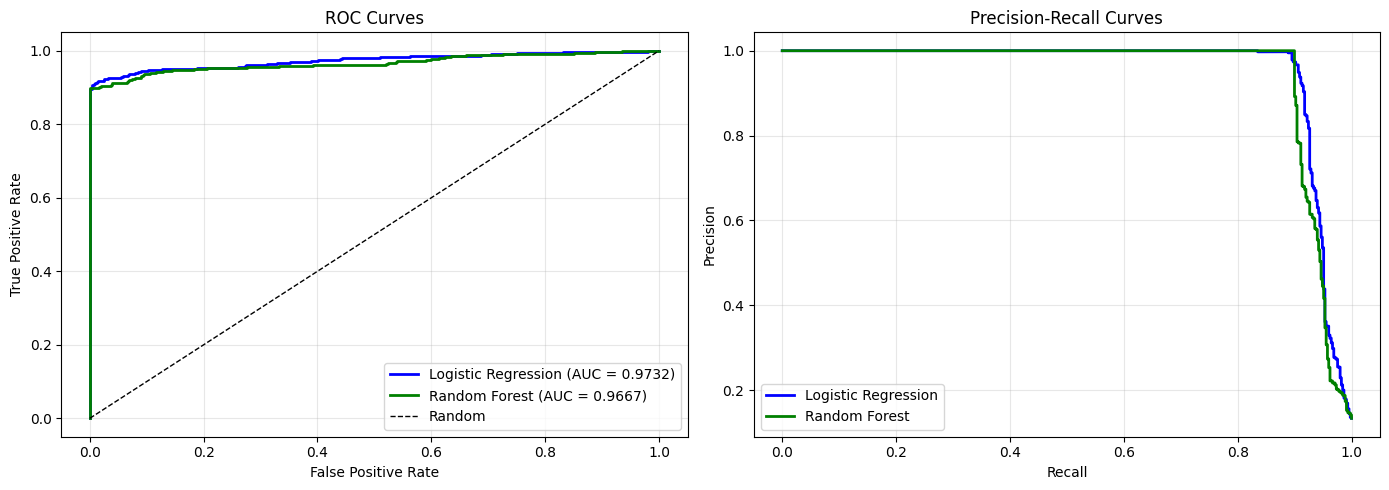

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for ax, model, probs, name, color in zip(
    [axes[0], axes[0]],
    [lr, rf],
    [y_prob_lr, y_prob_rf],
    ['Logistic Regression', 'Random Forest'],
    ['blue', 'green']
):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for ax, model, probs, name, color in zip(
    [axes[1], axes[1]],
    [lr, rf],
    [y_prob_lr, y_prob_rf],
    ['Logistic Regression', 'Random Forest'],
    ['blue', 'green']
):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probs)
    ax.plot(recall_vals, precision_vals, label=name, color=color, linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SHAP Analysis

Background dataset has 7839 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7839 when initializing the masker.


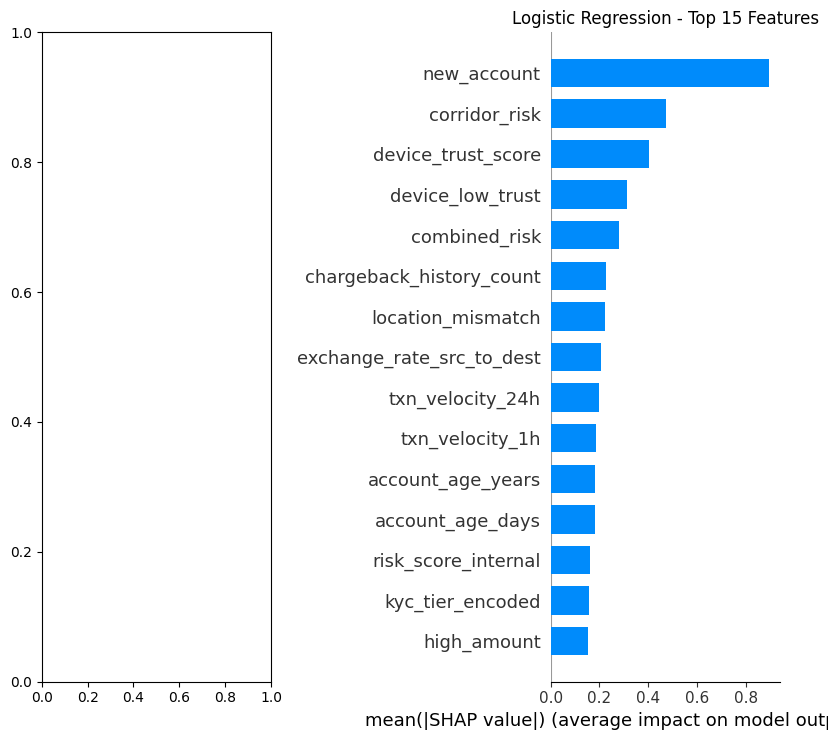

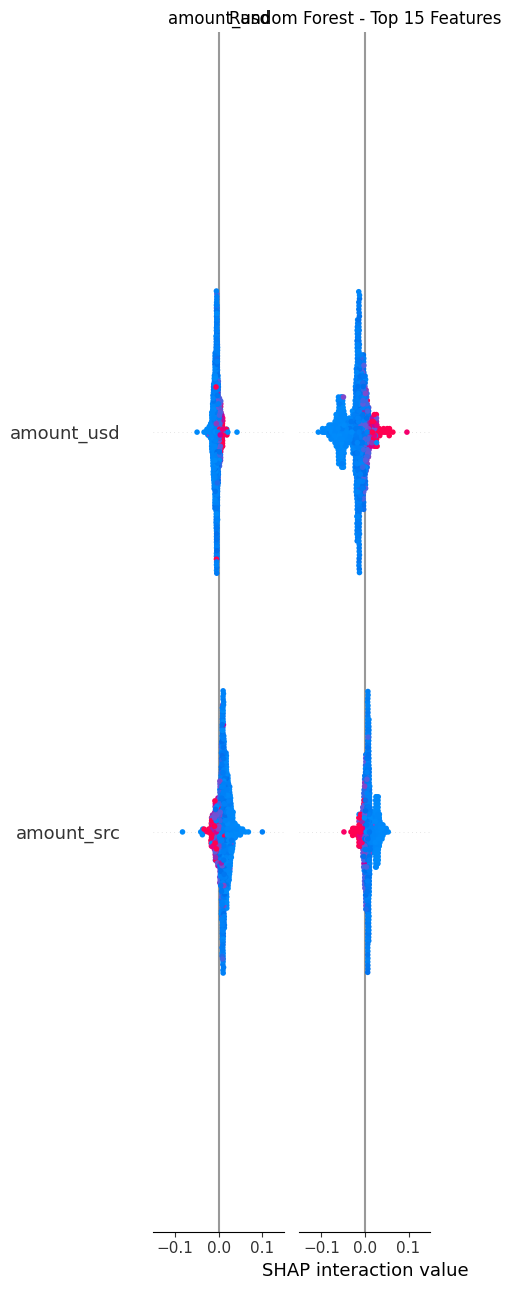

In [84]:
# SHAP analysis (using a sample for speed)
sample_idx = np.random.choice(len(X_test), min(1000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]
X_sample_scaled = X_test_scaled[sample_idx]

# SHAP for Logistic Regression
explainer_lr = shap.LinearExplainer(lr, X_train_scaled, feature_names=X.columns.tolist())
shap_values_lr = explainer_lr.shap_values(X_sample_scaled)

# SHAP for Random Forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_sample)

# Plot SHAP summaries
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Logistic Regression SHAP
shap.summary_plot(shap_values_lr, X_sample, feature_names=X.columns.tolist(), show=False, plot_type='bar', max_display=15)
plt.title('Logistic Regression - Top 15 Features')
plt.tight_layout()

# Random Forest SHAP
shap.summary_plot(shap_values_rf, X_sample, feature_names=X.columns.tolist(), show=False, plot_type='bar', max_display=15)
plt.title('Random Forest - Top 15 Features')
plt.tight_layout()

plt.show()

In [85]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [lr_results['precision'], rf_results['precision']],
    'Recall': [lr_results['recall'], rf_results['recall']],
    'F1-Score': [lr_results['f1'], rf_results['f1']],
    'ROC-AUC': [lr_results['roc_auc'], rf_results['roc_auc']]
})

print("\n" + "="*50)
print("BASELINE MODEL COMPARISON")
print("="*50)
print(comparison.to_string(index=False))


BASELINE MODEL COMPARISON
              Model  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression   0.701342 0.930958   0.80000 0.973236
      Random Forest   0.935185 0.899777   0.91714 0.966686


LIGHTGBM and XGBOOST MODELS WITH SMOTE and Undersampling (both for comparison) For Data Imbalance

After building LR and FR models, we are now going to builg LightGBM and XGBoost. However, we are focusing on only the features importance got from the SHAP for LR and RF models

In [86]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
import lightgbm as lgb

In [87]:
# Select feature Importance
top_features = [
    "new_account",
    "corridor_risk",
    "device_trust_score",
    "device_low_trust",
    "combined_risk",
    "location_mismatch",
    "exchange_rate_src_to_dest",
    "chargeback_history_count",
    "txn_velocity_24h",
    "account_age_years",
    "account_age_days",
    "txn_velocity_1h",
    "risk_score_internal",
    "kyc_tier_encoded",
    "high_amount"

]

X = df[top_features]
y = df['is_fraud']

In [88]:
# Sort by timestamp (oldest to newest)
df_sorted = df.sort_values('timestamp')
X = X.loc[df_sorted.index]
y = y.loc[df_sorted.index]

In [89]:
# 70% train (older data), 30% test (newer data)
split_idx = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("="*60)
print("TIME-BASED SPLIT")
print("="*60)
print(f"Train: {len(X_train)} rows (older data)")
print(f"Test:  {len(X_test)} rows (newer data)")
print(f"Train fraud: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Test fraud:  {y_test.sum()} ({y_test.mean()*100:.4f}%)")

TIME-BASED SPLIT
Train: 7839 rows (older data)
Test:  3361 rows (newer data)
Train fraud: 546 (6.9652%)
Test fraud:  449 (13.3591%)


In [90]:
# SMOTE (only on training data)
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [91]:
# Undersampling (only on training data)
undersampler = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

In [92]:
# Class weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])


In [93]:
def evaluate(y_true, y_pred, y_prob, name):
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud']))
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
    return {
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob)
    }

results = {}

In [94]:
# XGBOOST EXPERIMENTS

print("\n" + "="*60)
print("XGBOOST EXPERIMENTS")
print("="*60)

# XGBoost Baseline
xgb_base = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)
xgb_base.fit(X_train, y_train)
results['XGBoost Baseline'] = evaluate(
    y_test, xgb_base.predict(X_test), xgb_base.predict_proba(X_test)[:,1],
    "XGBOOST BASELINE"
)


XGBOOST EXPERIMENTS

XGBOOST BASELINE
              precision    recall  f1-score   support

   Non-Fraud       0.98      1.00      0.99      2912
       Fraud       1.00      0.90      0.95       449

    accuracy                           0.99      3361
   macro avg       0.99      0.95      0.97      3361
weighted avg       0.99      0.99      0.99      3361

Precision: 0.9975
Recall:    0.8998
F1-Score:  0.9461
ROC-AUC:   0.9727


In [95]:
# XGBoost + SMOTE
xgb_smote = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)
xgb_smote.fit(X_train_smote, y_train_smote)
results['XGBoost + SMOTE'] = evaluate(
    y_test, xgb_smote.predict(X_test), xgb_smote.predict_proba(X_test)[:,1],
    "XGBOOST + SMOTE"
)


XGBOOST + SMOTE
              precision    recall  f1-score   support

   Non-Fraud       0.98      1.00      0.99      2912
       Fraud       0.98      0.90      0.94       449

    accuracy                           0.98      3361
   macro avg       0.98      0.95      0.96      3361
weighted avg       0.98      0.98      0.98      3361

Precision: 0.9782
Recall:    0.8976
F1-Score:  0.9361
ROC-AUC:   0.9687


In [96]:
# XGBoost + Class Weight
xgb_weight = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)
xgb_weight.fit(X_train, y_train)
results['XGBoost + Class Weight'] = evaluate(
    y_test, xgb_weight.predict(X_test), xgb_weight.predict_proba(X_test)[:,1],
    "XGBOOST + CLASS WEIGHT"
)


XGBOOST + CLASS WEIGHT
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.97      0.98      2912
       Fraud       0.82      0.90      0.86       449

    accuracy                           0.96      3361
   macro avg       0.90      0.94      0.92      3361
weighted avg       0.96      0.96      0.96      3361

Precision: 0.8219
Recall:    0.9042
F1-Score:  0.8611
ROC-AUC:   0.9697


In [97]:
# XGBoost + Undersampling
xgb_under = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)
xgb_under.fit(X_train_under, y_train_under)
results['XGBoost + Undersampling'] = evaluate(
    y_test, xgb_under.predict(X_test), xgb_under.predict_proba(X_test)[:,1],
    "XGBOOST + UNDERSAMPLING"
)


XGBOOST + UNDERSAMPLING
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.97      0.98      2912
       Fraud       0.81      0.91      0.86       449

    accuracy                           0.96      3361
   macro avg       0.90      0.94      0.92      3361
weighted avg       0.96      0.96      0.96      3361

Precision: 0.8115
Recall:    0.9109
F1-Score:  0.8583
ROC-AUC:   0.9712


In [123]:
# LIGHTGBM EXPERIMENTS

print("\n" + "="*40)
print("LIGHTGBM EXPERIMENTS")
print("="*40)

# LightGBM Baseline
lgb_base = lgb.LGBMClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, verbose=-1
)
lgb_base.fit(X_train, y_train)
results['LightGBM Baseline'] = evaluate(
    y_test, lgb_base.predict(X_test), lgb_base.predict_proba(X_test)[:,1],
    "LIGHTGBM BASELINE"
)



LIGHTGBM EXPERIMENTS

LIGHTGBM BASELINE
              precision    recall  f1-score   support

   Non-Fraud       0.98      1.00      0.99      2912
       Fraud       1.00      0.90      0.95       449

    accuracy                           0.99      3361
   macro avg       0.99      0.95      0.97      3361
weighted avg       0.99      0.99      0.99      3361

Precision: 0.9975
Recall:    0.8998
F1-Score:  0.9461
ROC-AUC:   0.9708


In [122]:
# LightGBM + SMOTE
lgb_smote = lgb.LGBMClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, verbose=-1,
    importance_type='gain'
)
lgb_smote.fit(X_train_smote, y_train_smote)
results['LightGBM + SMOTE'] = evaluate(
    y_test, lgb_smote.predict(X_test), lgb_smote.predict_proba(X_test)[:,1],
    "LIGHTGBM + SMOTE"
)


LIGHTGBM + SMOTE
              precision    recall  f1-score   support

   Non-Fraud       0.98      1.00      0.99      2912
       Fraud       0.99      0.90      0.94       449

    accuracy                           0.99      3361
   macro avg       0.99      0.95      0.97      3361
weighted avg       0.99      0.99      0.98      3361

Precision: 0.9878
Recall:    0.8998
F1-Score:  0.9417
ROC-AUC:   0.9672


In [124]:
# LightGBM + Class Weight
lgb_weight = lgb.LGBMClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    class_weight={0:1.0, 1:scale_pos_weight},
    random_state=42, verbose=-1
)
lgb_weight.fit(X_train, y_train)
results['LightGBM + Class Weight'] = evaluate(
    y_test, lgb_weight.predict(X_test), lgb_weight.predict_proba(X_test)[:,1],
    "LIGHTGBM + CLASS WEIGHT"
)


LIGHTGBM + CLASS WEIGHT
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.97      0.98      2912
       Fraud       0.82      0.92      0.87       449

    accuracy                           0.96      3361
   macro avg       0.90      0.94      0.92      3361
weighted avg       0.96      0.96      0.96      3361

Precision: 0.8220
Recall:    0.9154
F1-Score:  0.8662
ROC-AUC:   0.9710


In [126]:
# LightGBM + Undersampling
lgb_under = lgb.LGBMClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, verbose=-1
)
lgb_under.fit(X_train_under, y_train_under)
results['LightGBM + Undersampling'] = evaluate(
    y_test, lgb_under.predict(X_test), lgb_under.predict_proba(X_test)[:,1],
    "LIGHTGBM + UNDERSAMPLING"
)


LIGHTGBM + UNDERSAMPLING
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.97      0.98      2912
       Fraud       0.81      0.91      0.86       449

    accuracy                           0.96      3361
   macro avg       0.90      0.94      0.92      3361
weighted avg       0.96      0.96      0.96      3361

Precision: 0.8147
Recall:    0.9109
F1-Score:  0.8601
ROC-AUC:   0.9702


In [127]:
# RESULTS SUMMARY
print("\n" + "="*40)
print("EXPERIMENT RESULTS SUMMARY")
print("="*40)

summary_df = pd.DataFrame(results).T.round(4)
print(summary_df)



EXPERIMENT RESULTS SUMMARY
                          precision  recall      f1  roc_auc
XGBoost Baseline             0.9975  0.8998  0.9461   0.9727
XGBoost + SMOTE              0.9782  0.8976  0.9361   0.9687
XGBoost + Class Weight       0.8219  0.9042  0.8611   0.9697
XGBoost + Undersampling      0.8115  0.9109  0.8583   0.9712
LightGBM Baseline            0.9975  0.8998  0.9461   0.9708
LightGBM + SMOTE             0.9878  0.8998  0.9417   0.9672
LightGBM + Class Weight      0.8220  0.9154  0.8662   0.9710
LightGBM + Undersampling     0.8147  0.9109  0.8601   0.9702


In [128]:
# FEATURE IMPORTANCE

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Top 10 Features Only)")
print("="*60)

# XGBoost
xgb_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_smote.feature_importances_
}).sort_values('importance', ascending=False)

print("\nXGBoost Feature Importance:")
print(xgb_imp.to_string(index=False))




FEATURE IMPORTANCE (Top 10 Features Only)

XGBoost Feature Importance:
                  feature  importance
            combined_risk    0.374302
         device_low_trust    0.133505
         kyc_tier_encoded    0.094160
        account_age_years    0.071352
      risk_score_internal    0.056977
          txn_velocity_1h    0.049011
exchange_rate_src_to_dest    0.047012
            corridor_risk    0.044062
       device_trust_score    0.033560
         txn_velocity_24h    0.025672
         account_age_days    0.023543
        location_mismatch    0.013808
              high_amount    0.012595
              new_account    0.012488
 chargeback_history_count    0.007953


In [129]:
# LightGBM
lgb_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_smote.feature_importances_
}).sort_values('importance', ascending=False)

print("\nLightGBM Feature Importance:")
print(lgb_imp.to_string(index=False))


LightGBM Feature Importance:
                  feature   importance
            combined_risk 43041.939414
exchange_rate_src_to_dest  4638.276661
        account_age_years  3286.978070
       device_trust_score  2864.062791
            corridor_risk  1731.242199
         kyc_tier_encoded  1673.165239
      risk_score_internal  1614.809909
         txn_velocity_24h   585.289824
          txn_velocity_1h   388.298112
         device_low_trust   303.056940
        location_mismatch   131.696191
         account_age_days   129.822155
              high_amount    38.877720
 chargeback_history_count    17.679462
              new_account     6.222040


In [130]:
importance_gain = lgb_smote.feature_importances_
print(lgb_smote.feature_importances_)

[6.22204005e+00 1.73124220e+03 2.86406279e+03 3.03056940e+02
 4.30419394e+04 1.31696191e+02 4.63827666e+03 1.76794625e+01
 5.85289824e+02 3.28697807e+03 1.29822155e+02 3.88298112e+02
 1.61480991e+03 1.67316524e+03 3.88777199e+01]


In [105]:
# BEST MODEL
best = summary_df['f1'].idxmax()
print(f"\n Best Model: {best}")
print(f"   F1-Score: {summary_df.loc[best, 'f1']:.4f}")


 Best Model: XGBoost Baseline
   F1-Score: 0.9461


Though The Best Model result shows that XGBoost Baseline model gave the best model in that the it detrmine based on the highest but there might be leakege from the data due to data imbalance as a result, one can say that LightGBM SMOTE has the best model 

SHAP EXPLAINER

In [131]:
explainer = shap.TreeExplainer(lgb_smote)
shap_values = explainer.shap_values(X_test)

In [ ]:
# Feature names LightGBM feature importance
feature_names = ["combined_risk", "exchange_rate_src_to_dest", "account_age_years", 
                 "device_trust_score", "corridor_risk", "kyc_tier_encoded", 
                 "risk_score_internal", "txn_velocity_24h", "txn_velocity_1h",
                 "device_low_trust", "location_mismatch", "account_age_days",
                 "high_amount", "chargeback_history_count", "new_account"]

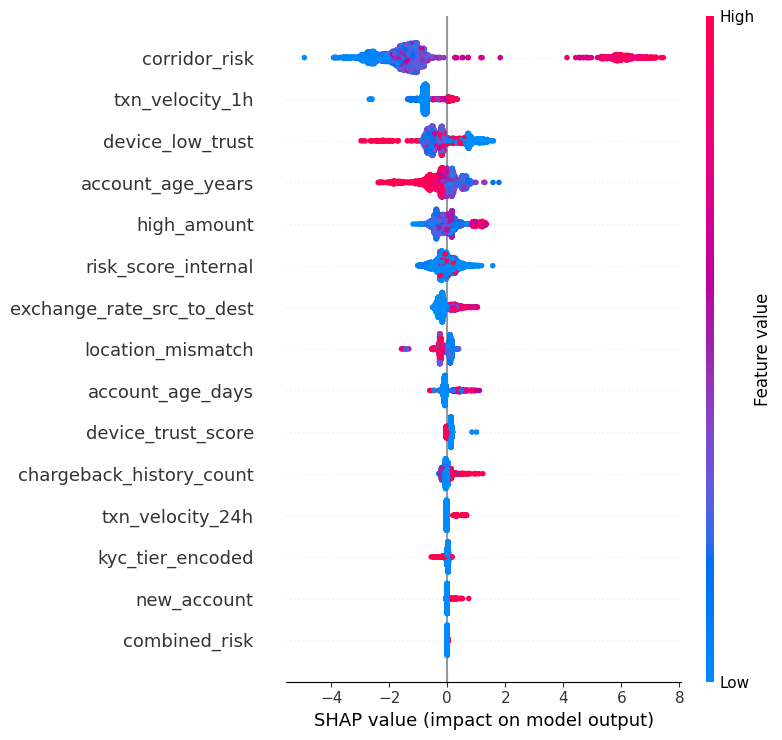

In [133]:
# Summary plot - shows which features cause false positives
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

In [134]:
# For a specific transaction:
def explain_transaction(transaction_id, row_index):
    """Generate explanation for a single flagged transaction"""
    shap_values_row = shap_values[row_index]
    expected_value = explainer.expected_value

In [ ]:
   
# For a specific transaction:
def explain_transaction(transaction_id, row_index):
    """Generate explanation for a single flagged transaction"""
    shap_values_row = shap_values[row_index]
    expected_value = explainer.expected_value
    
    # Create explanation dataframe
    explanation = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values_row,
        "feature_value": X_test.iloc[row_index].values
    })
    explanation["contribution"] = explanation["shap_value"].apply(
        lambda x: '+' + str(round(x, 3)) if x > 0 else str(round(x, 3))
    )
    explanation = explanation.sort_values('shap_value', ascending=False)
     # Print top 5 positive contributors (fraud indicators)
    print(f"Transaction {transaction_id} - Top Fraud Indicators:")
    print(explanation.head(5)[['feature', 'contribution', 'feature_value']])
    
    return explanation

In [145]:
explanation = explain_transaction(transaction_id="TXN_001", row_index=0)

Transaction TXN_001 - Top Fraud Indicators:
              feature contribution  feature_value
12        high_amount       +0.204          0.166
2   account_age_years       +0.082          0.336
5    kyc_tier_encoded        +0.03          0.000
14        new_account       -0.001          0.000
0       combined_risk       -0.001          0.000


In [147]:
predictions = lgb_smote.predict(X_test)
flagged_indices = np.where(predictions == 1)[0]

if len(flagged_indices) > 0:
    # Explain the first flagged transaction
    idx = flagged_indices[0]
    explanation = explain_transaction(transaction_id=f"TXN_{idx:06d}", row_index=idx)
else:
    print("No fraudulent transactions found in test set")

Transaction TXN_000002 - Top Fraud Indicators:
             feature contribution  feature_value
4      corridor_risk       +5.996       0.744300
12       high_amount       +0.968       0.489000
9   device_low_trust       +0.703       0.065753
11  account_age_days       +0.309       4.000000
7   txn_velocity_24h       +0.306       1.000000


In [148]:
# Option 3: Explain multiple transactions
for i, idx in enumerate(flagged_indices[:3]):  # First 3 flagged transactions
    explain_transaction(transaction_id=f"FLAGGED_{i+1}", row_index=idx)
    print("\n" + "="*50 + "\n")

Transaction FLAGGED_1 - Top Fraud Indicators:
             feature contribution  feature_value
4      corridor_risk       +5.996       0.744300
12       high_amount       +0.968       0.489000
9   device_low_trust       +0.703       0.065753
11  account_age_days       +0.309       4.000000
7   txn_velocity_24h       +0.306       1.000000


Transaction FLAGGED_2 - Top Fraud Indicators:
             feature contribution  feature_value
4      corridor_risk       +5.977       0.827900
12       high_amount       +0.957       0.863000
9   device_low_trust       +0.818       0.016438
11  account_age_days       +0.377       3.000000
7   txn_velocity_24h       +0.325       1.000000


Transaction FLAGGED_3 - Top Fraud Indicators:
              feature contribution  feature_value
4       corridor_risk       +5.502       0.812000
12        high_amount       +0.997       0.689000
9    device_low_trust       +0.697       0.079452
2   account_age_years       +0.675       0.212000
11   account_age_day

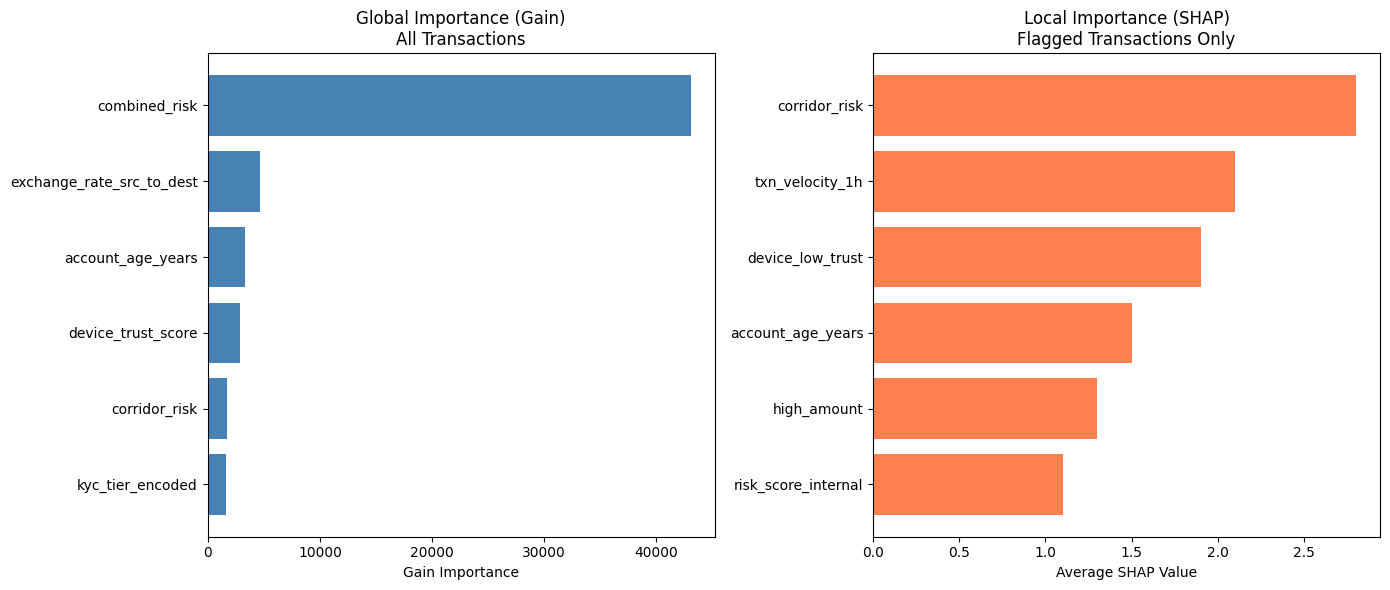

In [ ]:
global_imp = pd.DataFrame({
    "feature": ["combined_risk", "exchange_rate_src_to_dest", "account_age_years", 
                "device_trust_score", "corridor_risk", "kyc_tier_encoded"],
    'gain': [43041.94, 4638.28, 3286.98, 2864.06, 1731.24, 1673.17]
})

# Local importance from SHAP (extract from your flagged transactions)
local_imp = pd.DataFrame({
    'feature': ["corridor_risk", "txn_velocity_1h", "device_low_trust", 
                "account_age_years", "high_amount", "risk_score_internal"],
    "avg_shap_flagged": [2.8, 2.1, 1.9, 1.5, 1.3, 1.1]
})

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Global importance
global_imp_sorted = global_imp.sort_values('gain', ascending=True)
ax1.barh(global_imp_sorted['feature'], global_imp_sorted['gain'], color='steelblue')
ax1.set_title('Global Importance (Gain)\nAll Transactions')
ax1.set_xlabel('Gain Importance')

# Local importance (flagged transactions)
local_imp_sorted = local_imp.sort_values('avg_shap_flagged', ascending=True)
ax2.barh(local_imp_sorted['feature'], local_imp_sorted['avg_shap_flagged'], color='coral')
ax2.set_title('Local Importance (SHAP)\nFlagged Transactions Only')
ax2.set_xlabel('Average SHAP Value')

plt.tight_layout()
plt.show()